In [59]:
import numpy as np

def distance_metric(string1, string2):

    nasals = "mnŋ"
    fricatives = "fvθðh"
    plosives = "pbtdkg"
    sibilants = "sʃzʒʤʧ"
    rhotics = "r"
    vowels = "aəʊiɪeɛuʊɔæɒᵊ"
    laterals = "l"

    syl_space1 = {"n":0,"f":0,"p":0,"s":0,"r":0,"v":0,"l":0}
    syl_space2 = {"n":0,"f":0,"p":0,"s":0,"r":0,"v":0,"l":0}

    for char in string1:
        if char in nasals:
            syl_space1["n"] += 1
        if char in fricatives:
            syl_space1["f"] += 1
        if char in plosives:
            syl_space1["p"] += 1
        if char in sibilants:
            syl_space1["s"] += 1
        if char in rhotics:
            syl_space1["r"] += 1
        if char in vowels:
            syl_space1["v"] += 1
        if char in laterals:
            syl_space1["l"] += 1

    for char in string2:
        if char in nasals:
            syl_space2["n"] += 1
        if char in fricatives:
            syl_space2["f"] += 1
        if char in plosives:
            syl_space2["p"] += 1
        if char in sibilants:
            syl_space2["s"] += 1
        if char in rhotics:
            syl_space2["r"] += 1
        if char in vowels:
            syl_space2["v"] += 1
        if char in laterals:
            syl_space2["l"] += 1

    #print(syl_space1)
    #print(syl_space2)
    return np.linalg.norm(np.array(list(syl_space1.values())) - np.array(list(syl_space2.values())))




In [46]:
print(distance_metric("ɡraʊnd", "ʤɪn"))
print(distance_metric("ɪmæ", "θrəʊn"))
print(distance_metric("kɒ","θrɪld"))
print(distance_metric("ʧʌk","θrəʊn"))


{'n': 1, 'f': 0, 'p': 1, 's': 0, 'r': 1, 'v': 2, 'l': 0}
{'n': 1, 'f': 0, 'p': 0, 's': 1, 'r': 0, 'v': 1, 'l': 0}
2.0
{'n': 1, 'f': 0, 'p': 0, 's': 0, 'r': 0, 'v': 2, 'l': 0}
{'n': 1, 'f': 1, 'p': 0, 's': 0, 'r': 1, 'v': 2, 'l': 0}
1.4142135623730951
{'n': 0, 'f': 0, 'p': 1, 's': 0, 'r': 0, 'v': 1, 'l': 0}
{'n': 0, 'f': 1, 'p': 1, 's': 0, 'r': 1, 'v': 1, 'l': 1}
1.7320508075688772
{'n': 0, 'f': 0, 'p': 1, 's': 1, 'r': 0, 'v': 0, 'l': 0}
{'n': 1, 'f': 1, 'p': 0, 's': 0, 'r': 1, 'v': 2, 'l': 0}
3.0


In [58]:
import pandas as pd

stimuli = pd.read_excel("/home/alily/Downloads/TongueTwisterStimuli.ods")


len(stimuli["syll_IPA"])

62

In [56]:
import seaborn as sns

distances = []

for i in range(10):
    for j in range(10):
        dist = distance_metric(stimuli["syll_IPA"][i], stimuli["syll_IPA"][j])
        distances.append(dist)

distances = np.array(distances).reshape(10,10)

distances

array([[0.        , 2.        , 1.73205081, 2.23606798, 2.        ,
        2.        , 2.23606798, 2.        , 2.        , 2.23606798],
       [2.        , 0.        , 3.        , 1.73205081, 2.44948974,
        2.44948974, 2.23606798, 2.44948974, 1.41421356, 3.        ],
       [1.73205081, 3.        , 0.        , 2.        , 2.64575131,
        1.73205081, 2.        , 2.64575131, 2.23606798, 2.        ],
       [2.23606798, 1.73205081, 2.        , 0.        , 2.64575131,
        1.73205081, 1.41421356, 2.64575131, 1.        , 2.44948974],
       [2.        , 2.44948974, 2.64575131, 2.64575131, 0.        ,
        2.        , 1.73205081, 1.41421356, 2.        , 2.64575131],
       [2.        , 2.44948974, 1.73205081, 1.73205081, 2.        ,
        0.        , 1.        , 1.41421356, 1.41421356, 1.        ],
       [2.23606798, 2.23606798, 2.        , 1.41421356, 1.73205081,
        1.        , 0.        , 1.73205081, 1.        , 2.        ],
       [2.        , 2.44948974, 2.6457513

<Axes: >

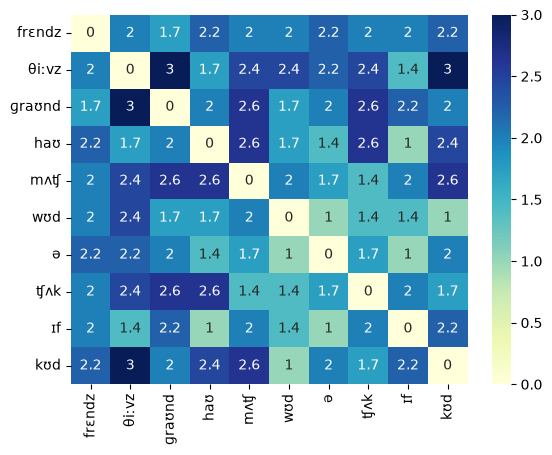

In [57]:
sns.heatmap(distances, annot=True, cmap="YlGnBu", xticklabels=stimuli["syll_IPA"][0:10], yticklabels=stimuli["syll_IPA"][0:10])